<a href="https://colab.research.google.com/github/reynaudnangue28/test/blob/main/CO2_Emission_Project_Data_Visualizations_French.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


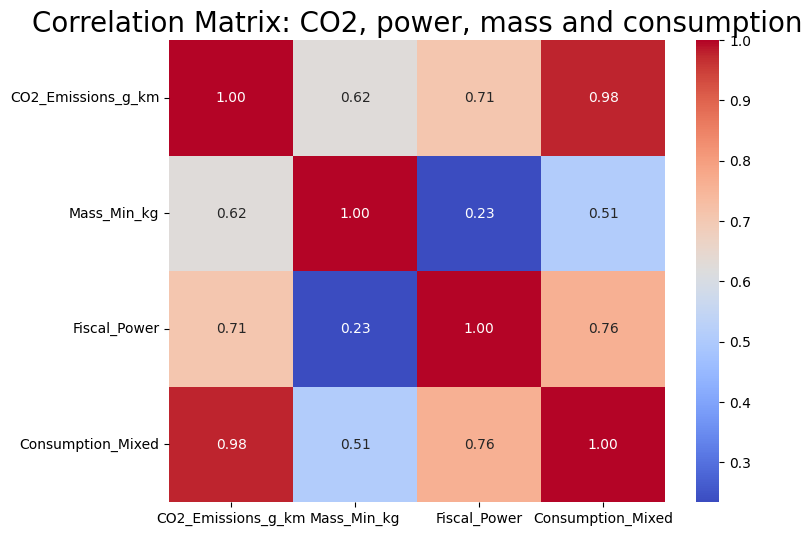

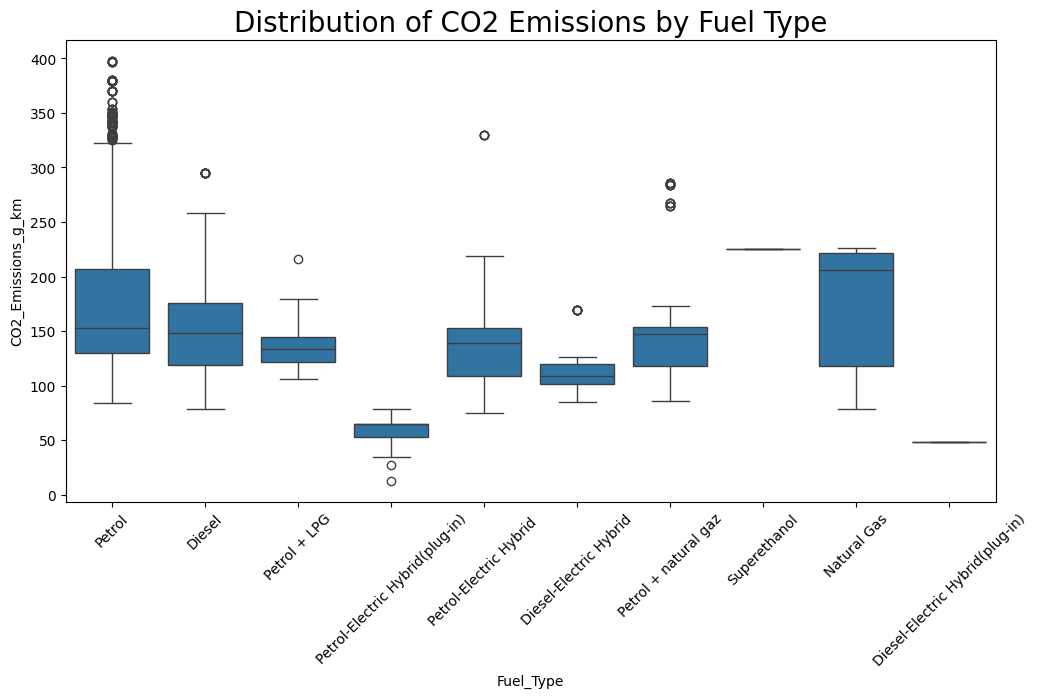

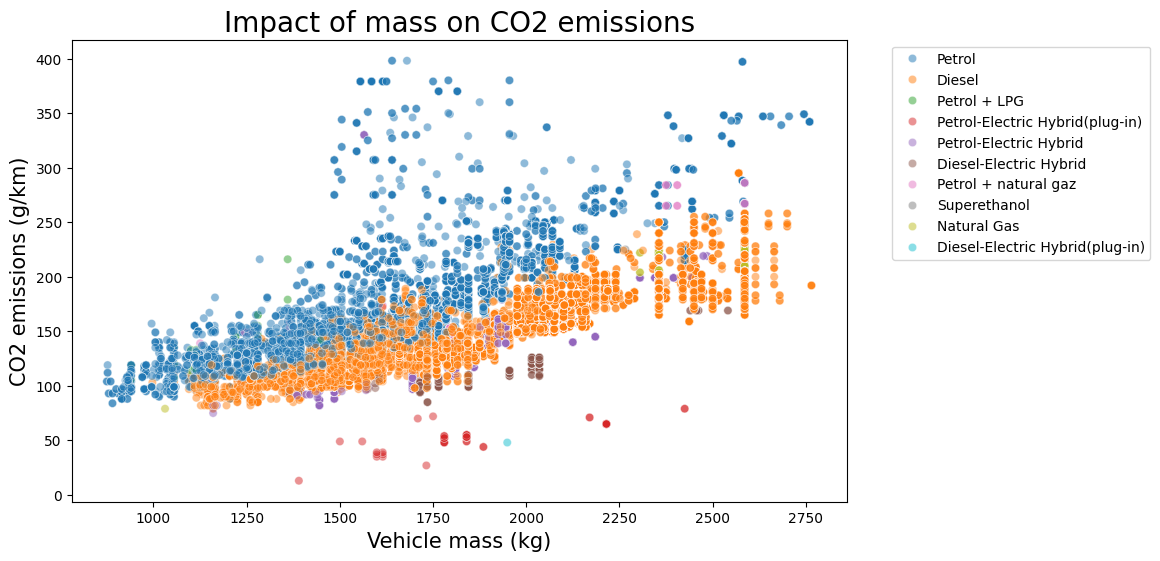

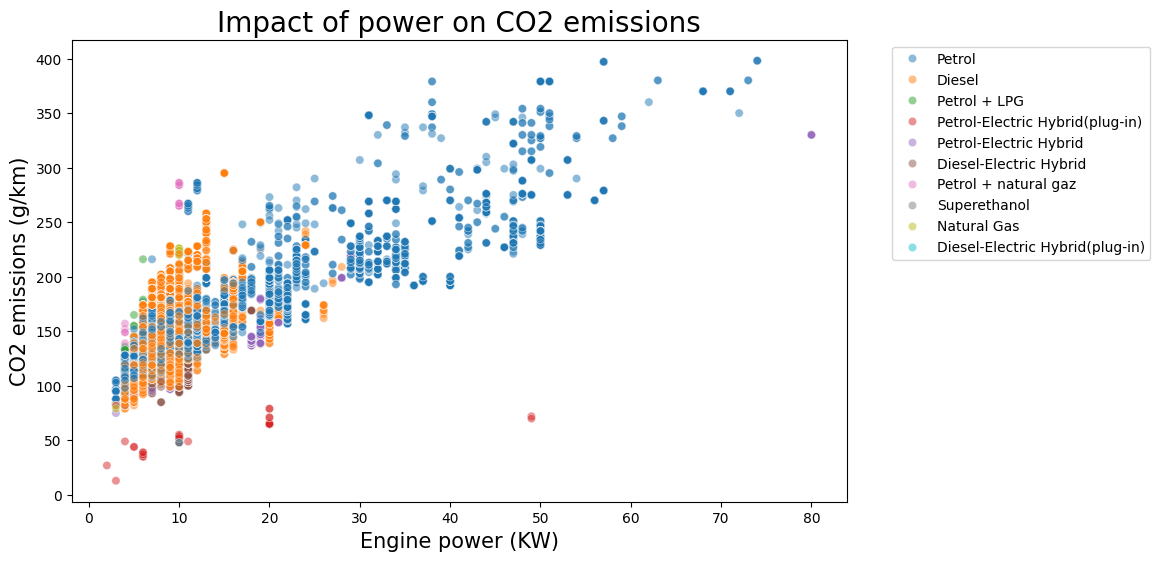

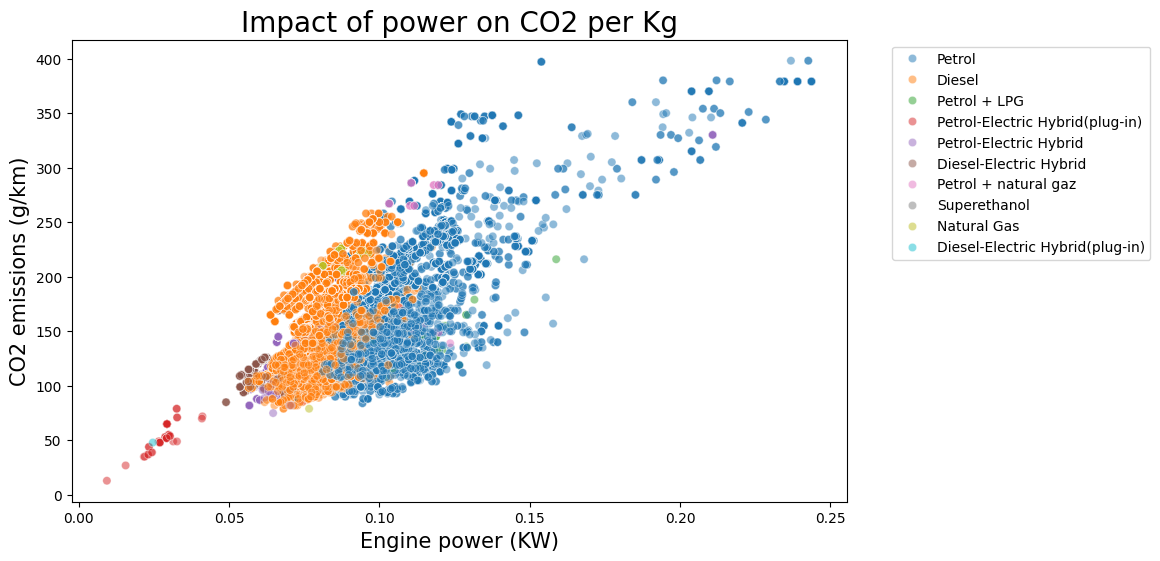

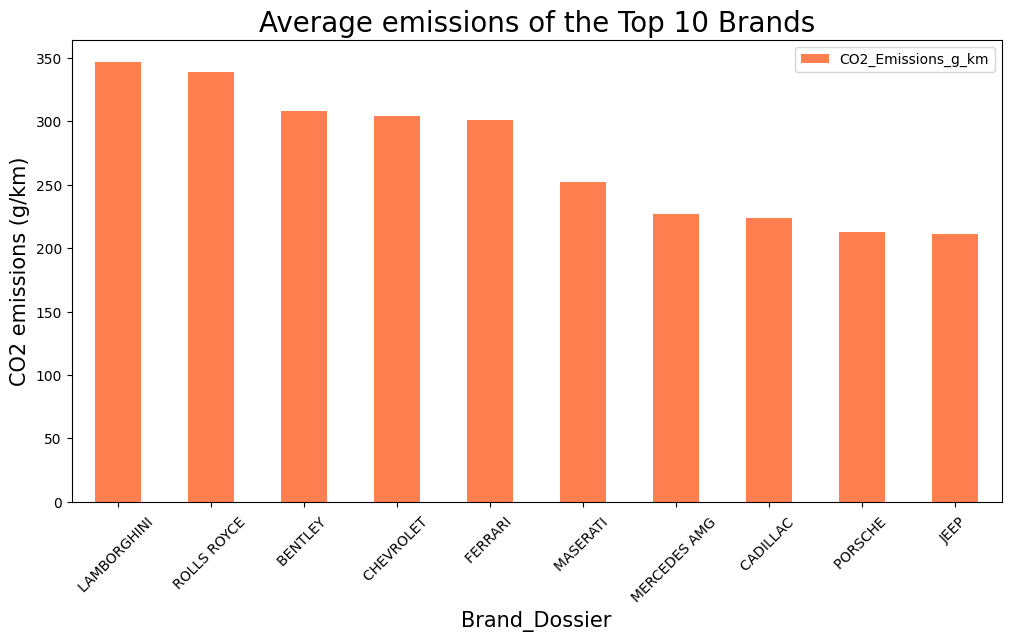

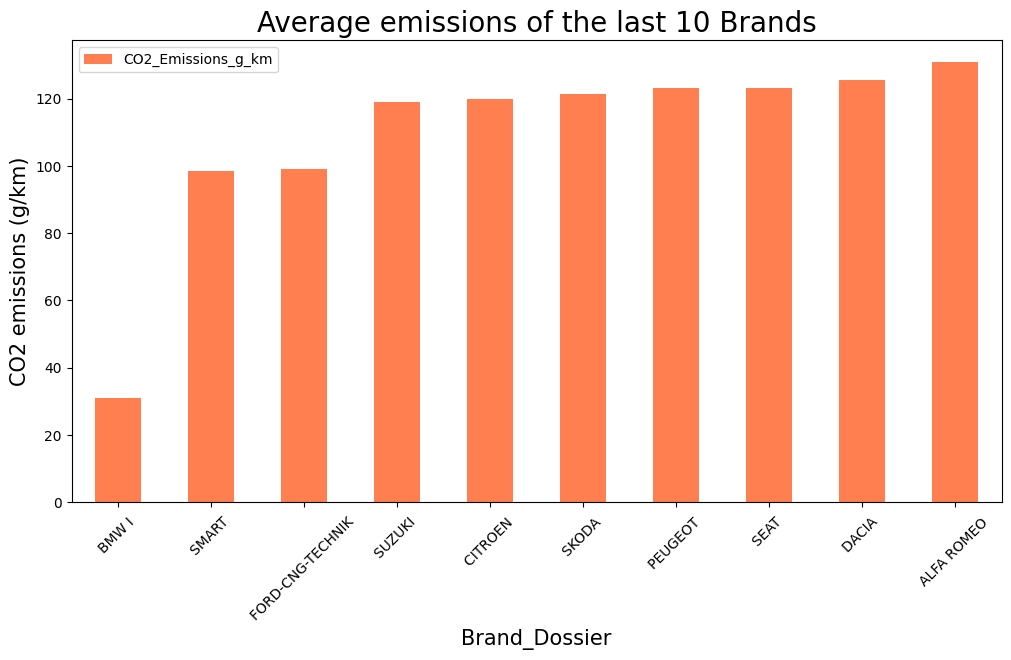

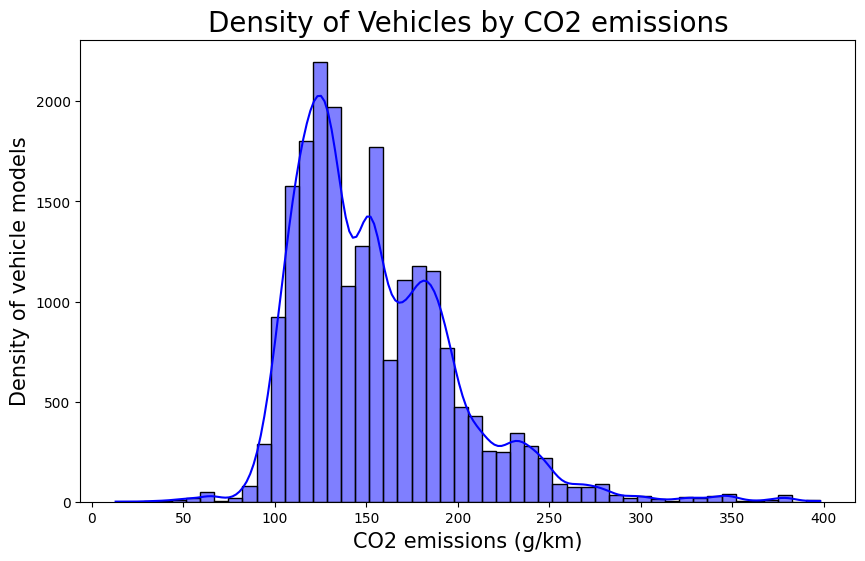

In [ ]:
import pandas as pd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

# Google Colab to access and mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# ---  load a mapping csv---
try:
    mapping_df = pd.read_csv('/content/drive/MyDrive/DataScienceProject/fr_column_mapping_with_nulls.csv')
    cols_to_keep = mapping_df[mapping_df['keep'] == True]
    rename_map = dict(zip(cols_to_keep['Column_name_original'], cols_to_keep['column_name_new']))
except FileNotFoundError:
    print("Error : file is missing.")
    exit()

# ---  load the french file  ---
file_path = '/content/drive/MyDrive/DataScienceProject/fic_etiq_edition_40-mars-2015.csv'
df = pd.read_csv(file_path, sep=';', encoding='latin-1')

# ---  Filter and rename ---
# choose only the columns with 'keep=True'
df = df[rename_map.keys()]
# Rename the columns
df = df.rename(columns=rename_map)

# --- end ---
df = df.dropna(subset=['CO2_Emissions_g_km', 'Mass_Min_kg'])
df['Fuel_Type'] = df['Fuel_Type'].replace({'ES': "Petrol",
                                   'GO ': "Diesel",
                                   'ES ': "Petrol",
                                   'EH ': "Petrol-Electric Hybrid ",
                                   'GH ': "Diesel-Electric Hybrid",
                                   'GL ': "Diesel-Electric Hybrid(plug-in)",
                                   'EE ': "Petrol-Electric Hybrid(plug-in)",
                                   'GN ': "Natural Gas",
                                   'EL ': "100% Electric",
                                    'GP/ES ' : "Petrol + LPG",
                                    'GN/ES ' : "Petrol + natural gaz",
                                   'ES/GP ': "Petrol + LPG",
                                   'ES/GN ': "Petrol + natural gaz",
                                   'GP ': "Liquefied Petroleum Gas",
                                   'FE ': "Superethanol"})

#Graphical presentations

# This helps you see the correlation between the relevant columns
#Select only the relevant numeric columns
plt.figure(figsize=(8, 6))
cols_to_correlate = ['CO2_Emissions_g_km', 'Mass_Min_kg',"Fiscal_Power", 'Consumption_Mixed']
correlation_matrix = df[cols_to_correlate].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix: CO2, power, mass and consumption', fontsize=20)
plt.show()

#Unlike a simple average, this shows the spread and outliers.
#You can see if certain "Green" brands actually have high-emission outliers in their catalog
plt.figure(figsize=(12, 6))
sns.boxplot(x='Fuel_Type', y='CO2_Emissions_g_km',data=df)
plt.xticks(rotation=45)
plt.title('Distribution of CO2 Emissions by Fuel Type', fontsize=20)
plt.show()

#This scatter plot identifies how weight affects emissions across different fuel types.
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df,x='Mass_Min_kg', y='CO2_Emissions_g_km',hue='Fuel_Type', alpha=0.5)
plt.title('Impact of mass on CO2 emissions',fontsize=20)
plt.xlabel('Vehicle mass (kg)', fontsize=15)
plt.ylabel('CO2 emissions (g/km)',fontsize=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#This scatter plot identifies how power affects emissions across different fuel types.
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df,x='Fiscal_Power', y='CO2_Emissions_g_km',hue='Fuel_Type', alpha=0.5)
plt.title('Impact of power on CO2 emissions',fontsize=20)
plt.xlabel('Engine power (KW)',fontsize=15)
plt.ylabel('CO2 emissions (g/km)',fontsize=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


# Identify which manufacturers had the lowest average fuel consumption in 2015
plt.figure(figsize=(12, 6))
brand_means = df.groupby('Brand_Dossier')['CO2_Emissions_g_km'].mean().sort_values(ascending=False).head(10)
brand_means.plot(kind='bar', color='coral')
#plt.axhline(y=95, color='green', linestyle='--', label='Cible UE 2026 (~95g/km)')
plt.title('Average emissions of the Top 10 Brands',fontsize=20)
plt.ylabel('CO2 emissions (g/km)',fontsize=15)
plt.xlabel('Brand_Dossier', fontsize=15)
plt.xticks(rotation=45)
plt.legend()
plt.show()

# Identify which manufacturers had the lowest average fuel consumption in 2015
plt.figure(figsize=(12, 6))
brand_means = df.groupby('Brand_Dossier')['CO2_Emissions_g_km'].mean().sort_values(ascending=True).head(10)
brand_means.plot(kind='bar', color='coral')
#plt.axhline(y=95, color='green', linestyle='--', label='Cible UE 2026 (~95g/km)')
plt.title('Average emissions of the last 10 Brands',fontsize=20)
plt.ylabel('CO2 emissions (g/km)',fontsize=15)
plt.xlabel('Brand_Dossier', fontsize=15)
plt.xticks(rotation=45)
plt.legend()
plt.show()

#It pinpoints the most common emission levels (the "peak") to see where 2015 engine technology was most concentrated
plt.figure(figsize=(10, 6))
sns.histplot(df['CO2_Emissions_g_km'], kde=True, color='blue', bins=50)
plt.title('Density of Vehicles by CO2 emissions', fontsize=20)
plt.xlabel('CO2 emissions (g/km)', fontsize=15)
plt.ylabel('Density of vehicle models', fontsize=15 )
plt.show()